# HW-3: Pre-trained computer vision models 

Author: J. Hickman

**Overview:**

* In deep learning we don't always have to train our neural networks from scratch
* Often "pre-trained models" exist which we can "pull of the shelf" and use as part of a data processing pipeline. 
* In this assignment, we will use the popular "You only look once" (YOLO) deep learning algorithm to do object detection.
  * https://pytorch.org/hub/ultralytics_yolov5/
* Assume you are working for a company interested in traffic patterns and driver behavior 
  * For example, a car-insurance company, a traffic data analytics firm, or a self driving car start-up 
* This company has "dash-camera" footage from various cars in their "fleet" 
* As an initial proof of concept they want you to write a code to track the locations of other vehicles from the recordings 
* They also want you to analyze the time-dependence of traffic patterns found in the videos.

**Submission:**

* You need to upload ONE document to Canvas when you are done
  * (1) A PDF (or HTML) of the completed form of the "HW-3.ipynb" document 
* The final uploaded version should NOT have any code-errors present 
* All outputs must be visible in the uploaded version, including code-cell outputs, images, graphs, etc

**Note**:

* There are many ways to do this assignment and the methods below are guidelines not rules.
* If you find more efficient ways to complete the objectives then feel free to do it however you want. 
* **IMPORTANT: START SMALL THEN SCALE UP** 
  * Get everything working for a simple case with a few images, once everything seems to be working correctly then run it on the entire data set

**Data source**:

* Dash cam footage: https://www.youtube.com/watch?v=9qy4lExIetk
* Website to download youtube videos: https://en.y2mate.is/67/



### Import

In [1]:
import torch
from IPython.display import Image
import matplotlib.pyplot as plt
import shutil 
import cv2
import os

print(torch.__version__)

2.5.1


#### Part-3.0 

Open the file "video-res-2.mp4" and watch a few minutes to get familiar with the content

#### Part-3.1: Pre-processing

* The video is 2hr8min55s which is 2*60*60+8*60+55=7735 seconds 
* The frame rate for the video is roughly 30 frames per second 
* So there are around 7735*30=232050 frames
* Write code to read and convert the video "video-res-2.mp4" into an ORDERED set of images 
* Include a parameter to save frames every N seconds 
* Don't save every frame, at first save frames every 50 seconds, that will be around 155 images
* Once everything is working, save frames every 10 seconds and re-run the code for the final product.
* Save the images to a folder "frames" with the convention 
  * "frames/00010.jpg" for the frame 10 seconds into the video
  * "frames/00020.jpg" for the frame 20 seconds into the video and so on


In [2]:
# Paths
video_path = "video-res-2.mp4"
output_dir = "frames"
os.makedirs(output_dir, exist_ok=True)

# Video Catpure Method
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)

# Loop through seconds
save_interval = 10
max_frames = None
frame_num = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    second = frame_num / fps
    
    # Check if this frame is at a second mark
    prev_second = (frame_num - 1) / fps
    if int(second / save_interval) != int(prev_second / save_interval):
        timestamp = int(round(second / save_interval)) * save_interval
        cv2.imwrite(f"{output_dir}/{timestamp:05d}.jpg", frame)
    
    frame_num += 1

#### Part-3.2: Explore the model 

Before processing the video data, we want to make sure we can get YOLO working correctly for a few images

In [3]:
# Loading the Yolo Model
model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

Using cache found in /home/arige/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2026-2-23 Python-3.9.25 torch-2.5.1 CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


In [4]:
# AT FIRST USE THE FOLLOWING IMAGES AS A TEST CASE
images=['frames/00050.jpg','frames/00200.jpg']  

In [5]:
# INSERT CODE TO EVALUATE THE YOLO MODEL ON THESE IMAGES
results = model(images)

/home/arige/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


In [6]:
# WHEN WORKING IN PYTHON WITH AN OBJECT OF AN UN-FAMILIAR CLASS IT IS 
# VERY USEFUL TO FIGURE OUT THE CLASSES ATTRIBUTES AND METHOD
print(type(results))

<class 'models.common.Detections'>


In [7]:
# INSERT CODE TO FIGURE OUT WHAT THE OBJECTS ATTRIBUTES OF THE "results" OBJECT ARE
print(results.__dict__.keys())

dict_keys(['ims', 'pred', 'names', 'files', 'times', 'xyxy', 'xywh', 'xyxyn', 'xywhn', 'n', 't', 's'])


In [8]:
#  INSERT CODE TO FIGURE OUT WHAT THE OBJECTS METHODS OF THE "results" OBJECT ARE
print(dir(results))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_run', 'crop', 'files', 'ims', 'n', 'names', 'pandas', 'pred', 'print', 'render', 's', 'save', 'show', 't', 'times', 'tolist', 'xywh', 'xywhn', 'xyxy', 'xyxyn']


In [9]:
# PRINT A SUMMARY OF THE RESULT
results.print()

image 1/2: 240x426 4 cars, 1 truck, 1 boat
image 2/2: 240x426 4 cars, 3 trucks
Speed: 12.4ms pre-process, 58.5ms inference, 2.8ms NMS per image at shape (2, 3, 384, 640)


In [10]:
#THE INFORMATION ABOUT THE BOUNDING BOXES CAN BE EXTRACTED AS FOLLOWS
print(results.pandas().xyxy[1])

         xmin        ymin        xmax        ymax  confidence  class   name
0  288.887054  122.929092  329.875031  164.954987    0.872330      7  truck
1  362.652130  148.015640  426.000000  182.941162    0.853098      2    car
2  116.446114  130.873688  189.666840  182.079025    0.793491      7  truck
3  239.950638  146.331039  282.341278  176.735153    0.718554      2    car
4  204.539261  144.750488  220.252167  157.430481    0.360912      2    car
5  229.301819  138.106674  263.733246  164.564896    0.338887      7  truck
6  231.672089  143.345505  261.554993  167.486588    0.252074      2    car


In [11]:
# INSERT CODE TO REMOVE THE FOLDER "runs" IF IT EXISTS THEN RUN "results.save()"
if os.path.exists("runs"):
    shutil.rmtree("runs")

results.save()

Saved 2 images to runs/detect/exp


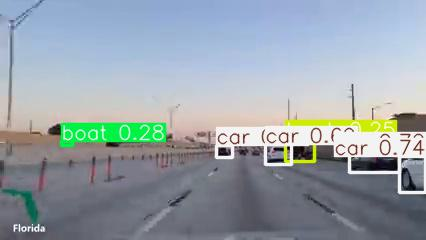

In [12]:
# LOOK AT THE FIRST IMAGE
Image("runs/detect/exp/00050.jpg")

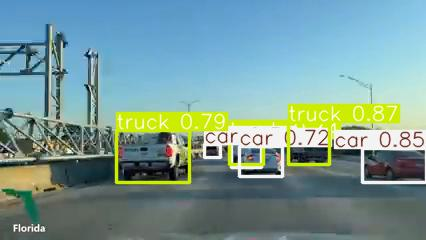

In [13]:
Image("runs/detect/exp/00200.jpg")

#### Part-3.3: Explore the results  

The following code will plot the image and add a vertical line roughly down the center of the car's hood

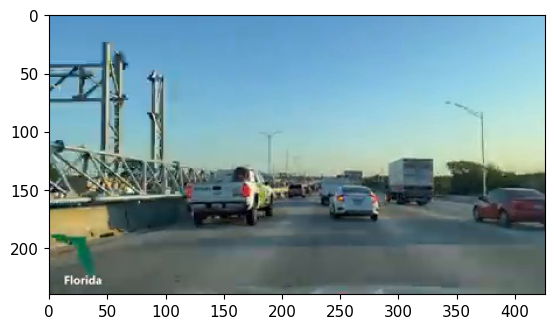

In [14]:
%matplotlib inline
plt.imshow(results.ims[1])
plt.show()

image 1/2: 240x426 4 cars, 1 truck, 1 boat
image 2/2: 240x426 4 cars, 3 trucks
Speed: 12.4ms pre-process, 58.5ms inference, 2.8ms NMS per image at shape (2, 3, 384, 640)


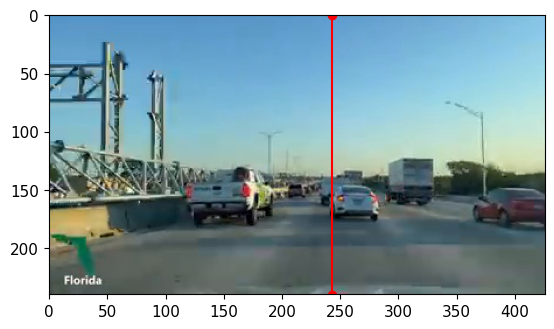

In [15]:
#PLOT IMAGE WITH REGIONAL SUB-DIVIDING LINES
def plot_lines(img):
    YMAX=img.shape[0]
    XMAX=img.shape[1]
    XCENTER=0.57*XMAX

    x1 = XCENTER; y1 = 0; x2 = XCENTER; y2 = YMAX 
    plt.plot([x1,x2], [y1,y2], marker = 'o',color="red")
    plt.imshow(img)
    plt.show()

results.print()
plot_lines(results.ims[1])



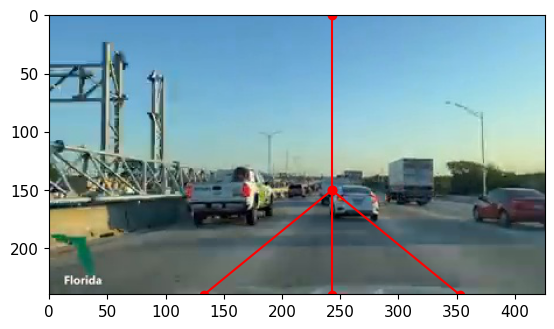

In [16]:
# INSERT CODE TO MODIFY THE FUNCTION TO GENERATE THE FOLLOWING IMAGE TO ROUGHLY ISOLATE THE LANE
# YOU CAN JUST USE GEOMETRY TO DO THIS
img = results.ims[1]
YMAX=img.shape[0]
XMAX=img.shape[1]
XCENTER=0.57*XMAX

x1 = XCENTER; y1 = 0; x2 = XCENTER; y2 = YMAX 
plt.plot([x1,x2], [y1,y2], marker = 'o',color="red")
plt.plot([XCENTER-110,XCENTER],[y2,150], marker = 'o',color="red")
plt.plot([XCENTER+110,XCENTER],[y2,150], marker = 'o',color="red")
plt.imshow(img)
plt.show()

Insert a function to output a modified version of the results.pandas().xyxy[i] data-frame in the following ways 

* normalize (scale) the xmin, xmax by the width of the image and ymin, ymax by the height --> HxW=1x1 
* compute the area and center of each box using the normalized coordinates
* add a column named "nearby" which is True if normalized_area>0.05
* **Optional**: Use The geometric lane construction from the previous image and the location of the box center to compute which lane (left,center,right) nearby vehicles are in
 
```
       xmin      ymin      xmax      ymax  confidence  ...   name nearby  \
0  0.677506  0.515625  0.771468  0.680202    0.859959  ...  truck  False   
1  0.831234  0.617149  0.977826  0.743249    0.851794  ...    car  False   
2  0.002621  0.457946  0.410202  0.926958    0.820941  ...  truck   True   
3  0.547734  0.598833  0.656238  0.750011    0.581989  ...    car  False   
4  0.473275  0.594087  0.518594  0.662508    0.503990  ...    car  False   

       area  x_center  y_center  
0  0.015464  0.724487  0.597913  
1  0.018485  0.904530  0.680199  
2  0.191160  0.206412  0.692452  
3  0.016403  0.601986  0.674422  
4  0.003101  0.495935  0.628297  
```

In [17]:
#INSERT CODE TO MODIFY THE DATAFRAME 
def modify_xyxy(results, img_idx=0):
    img = results.ims[img_idx]
    df = results.pandas().xyxy[img_idx].copy()

    # Normalizing by image shape
    H, W = img.shape[:2]
    
    df['xmin'] = df['xmin'] / W
    df['xmax'] = df['xmax'] / W
    df['ymin'] = df['ymin'] / H
    df['ymax'] = df['ymax'] / H

    # Compute the area and center of each box using the normalized coordinates
    df['area']   = (df['xmax'] - df['xmin']) * (df['ymax'] - df['ymin'])
    df['x_center']    = (df['xmin'] + df['xmax']) / 2
    df['y_center']    = (df['ymin'] + df['ymax']) / 2

    # Nearby column
    df['nearby'] = df['area'] > 0.05

    return df

In [18]:
df = modify_xyxy(results, img_idx=0)
df

,xmin,ymin,xmax,ymax,confidence,...,name,area,x_center,y_center,nearby
0,0.938053,0.653972,0.999197,0.801603,0.735528,...,car,0.009027,0.968625,0.727787,False
1,0.819581,0.626236,0.937025,0.720562,0.716542,...,car,0.011078,0.878303,0.673399,False
2,0.624118,0.602863,0.684259,0.687305,0.693480,...,car,0.005078,0.654188,0.645084,False
3,0.507612,0.606604,0.545298,0.657010,0.466553,...,car,0.001900,0.526455,0.631807,False
4,0.143529,0.589797,0.171230,0.607061,0.277618,...,boat,0.000478,0.157379,0.598429,False
5,0.670172,0.576348,0.738779,0.671006,0.251598,...,truck,0.006494,0.704476,0.623677,False


### Part-3.4: Process all images

In [ ]:
# INSERT CODE TO FORM AN ORDERED (SORTED) LIST OF ALL IMAGES IN "frames" 
images = sorted([f"frames/{f}" for f in os.listdir("frames") if f.endswith(".jpg")])

: 

In [ ]:
# INSERT CODE TO RUN YOLO ON THE COMPLETE LIST
results = model(images)

/home/arige/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


In [ ]:
results.save()

Saved 154 images to runs/detect/exp2


### Part-3.5: Time-series analysis 

Loop over the results and build arrays with time-series data for the following 
* The frames should be ordered so you can treat the index as a "time" variables
* Total number num_cars and num_trucks in each frame
* num_neighbor = Number of neighboring cars and trucks (use normalized box area > .05 to signify a nearby car or truck)

In [ ]:
test = modify_xyxy(results, img_idx=50)
test

,xmin,ymin,xmax,ymax,confidence,...,name,area,x_center,y_center,nearby
0,0.433465,0.613540,0.498335,0.695432,0.779825,...,car,0.005312,0.465900,0.654486,False
1,0.561563,0.625157,0.581726,0.655605,0.370667,...,car,0.000614,0.571645,0.640381,False


In [ ]:
# 3.5.1: INSERT CODE TO LOOP OVER RESULTS AND BUILD ARRAYS
cars = []
trucks = []
nearby = []
for i in range(len(images)):
    # Create df
    df = modify_xyxy(results, img_idx=i)

    # Counts
    cars.append(int((df['name'] == 'car').sum()))
    trucks.append(int((df['name'] == 'truck').sum()))
    nearby.append(int(df['nearby'].sum()))

print("CAR \n", cars)
print("TRUCKS \n", trucks)
print("NEARBY \n", nearby)

CAR 
 [4, 6, 5, 4, 7, 6, 2, 5, 7, 3, 7, 2, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 5, 0, 1, 0, 1, 0, 4, 2, 3, 1, 2, 0, 4, 2, 1, 2, 1, 2, 0, 1, 1, 1, 0, 2, 3, 1, 2, 2, 4, 3, 4, 5, 1, 1, 0, 0, 1, 0, 0, 2, 1, 1, 2, 1, 1, 0, 0, 0, 0, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 1, 1, 3, 2, 2, 0, 1, 2, 1, 1, 2, 2, 1, 3, 1, 1, 1, 3, 1, 2, 4, 3, 1, 3, 1, 0, 1, 1, 1, 1, 4, 1, 5, 3, 3, 4, 6, 4, 2, 3, 11, 4, 7, 3, 0, 4, 3, 6, 1, 2, 4, 0, 2, 4, 4, 2, 1, 1, 0, 2, 1, 4, 6, 5, 1, 0, 1, 3, 1, 4, 4, 3]
TRUCKS 
 [1, 1, 1, 3, 2, 5, 3, 0, 2, 2, 1, 1, 2, 1, 0, 0, 1, 1, 2, 2, 2, 3, 1, 2, 0, 1, 0, 0, 1, 1, 4, 0, 2, 4, 1, 3, 2, 1, 4, 1, 3, 2, 2, 1, 1, 1, 2, 3, 3, 2, 0, 1, 1, 2, 1, 3, 0, 1, 1, 3, 0, 1, 2, 2, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 1, 2, 1, 1, 1, 1, 1, 2, 3, 1, 3, 1, 0, 1, 1, 0, 1, 4, 0, 1, 2, 3, 3, 0, 3, 1, 0, 0, 1, 1, 1, 1, 0, 1, 3, 1, 4, 1, 3, 2, 1, 1, 3, 0, 1, 0, 2, 2, 0, 0, 1, 0, 1, 3, 2, 0, 1, 1, 1, 3, 0, 4, 1, 2, 1, 1, 1, 1, 2, 2, 0, 0, 1, 3, 2, 0, 0, 0, 1, 0]
NEARBY 
 [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 

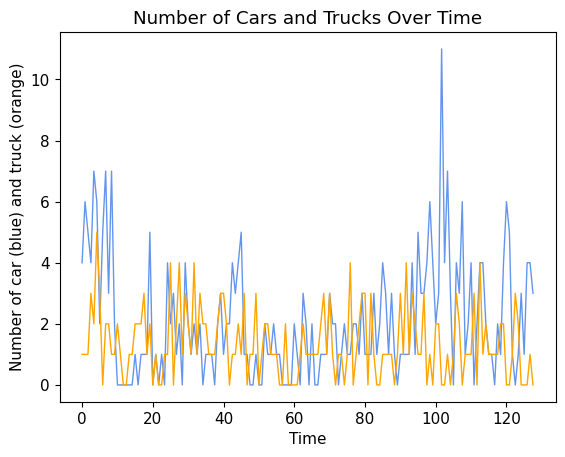

In [ ]:
# INSERT CODE TO GENERATE THE FOLLOWING PLOT
# save_interval = 50
time = [i * save_interval/60 for i in range(len(cars))]  

plt.plot(time, cars, color='cornflowerblue', label='cars',linewidth=1)
plt.plot(time, trucks, color='orange', label='trucks',linewidth=1)
plt.xlabel('Time')
plt.ylabel('Number of car (blue) and truck (orange)')
plt.title('Number of Cars and Trucks Over Time')
plt.show()

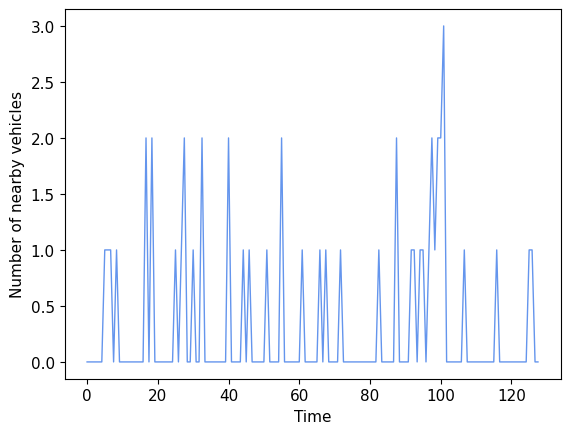

In [ ]:
# INSERT CODE TO GENERATE THE FOLLOWING PLOT
plt.plot(time, nearby, color='cornflowerblue', label='nearby',linewidth=1)
plt.xlabel('Time')
plt.ylabel('Number of nearby vehicles')
plt.show()

### Optional: Dynamic analysis (more advanced)

* Save more frames and see if you can write a script to track near-by neighboring cars from one frame to the next
  * Using this information, compute some measure of relative velocity of passing cars 
  * Plot this average velocity as a time series and discuss the meaning
* Research the mathematics of "perspective" and see if you can encode the math to predict an estimate for the distance to neighboring vehicles from the area of the box
  
